
--- Iteration: 30 ---
New column(s) added with minimum reduced cost: 0.022682196864154826

--- Iteration: 60 ---
New column(s) added with minimum reduced cost: 0.03160502447678707

--- Iteration: 90 ---
New column(s) added with minimum reduced cost: 0.009275774985258126

--- Iteration: 120 ---
New column(s) added with minimum reduced cost: 0.0045064145284031045

--- Iteration: 150 ---
New column(s) added with minimum reduced cost: 0.0010762474859289202

--- Column Generation Complete ---
No more profitable columns found. Optimal LP solution reached.

Final Modularity of the solution: 0.4197896120973044


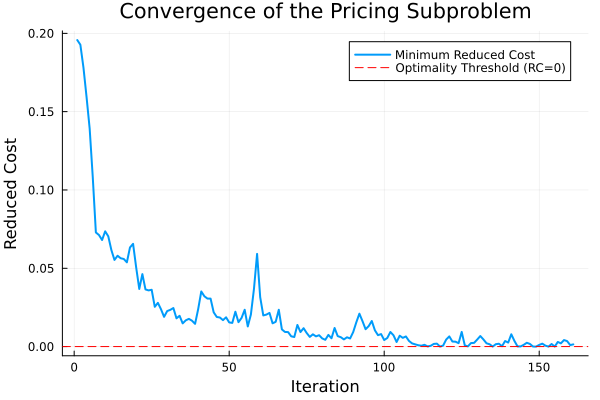

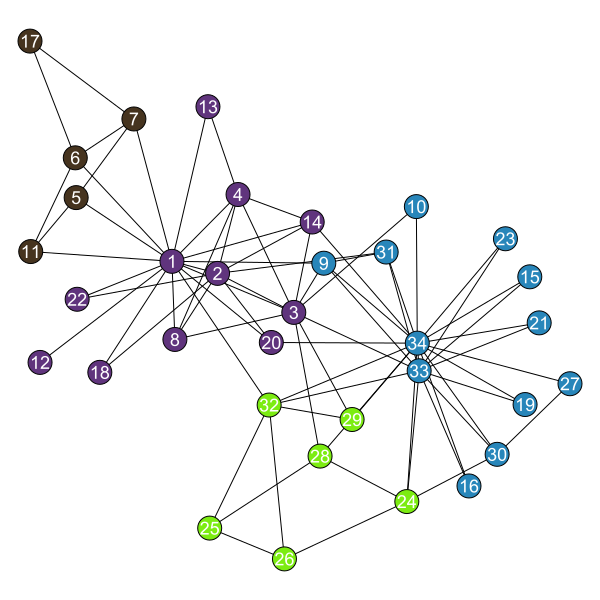

In [7]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: Exercises 2
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using Plots      # For plotting
using Random     # For random number generation
using Graphs     # For graph data structures
using Karnak     # For graph visualization
using Colors     # For color handling

# Define a structure to hold column information
mutable struct CPPColumn
    cost::Float64
    assignments::Vector{Int64}
end

# Function to plot the convergence of reduced costs
function plot_reduced_costs(reduced_cost_history)
    p = Plots.plot(
        1:length(reduced_cost_history), 
        reduced_cost_history,
        label="Minimum Reduced Cost",
        xlabel="Iteration",
        ylabel="Reduced Cost",
        title="Convergence of the Pricing Subproblem",
        legend=:topright,
        linewidth=2
    )
    # Add a horizontal line at y=0 to show the convergence target
    Plots.hline!(p, [0], linestyle=:dash, color=:red, label="Optimality Threshold (RC=0)")
    # Display the plot
    display(p)
end

# Function to print the graph with vertex colors based on solution
function print_solution(graph, solution = nothing)
    n = Graphs.nv(graph)
    if isnothing(solution)
        vertexfillcolors = fill(Colors.RGB(0, 0, 0), n)
    else
        colors = [Colors.RGB(rand(), rand(), rand()) for _ in 1:n]
        vertexfillcolors = [colors[solution[v]] for v in 1:n]
    end
    @drawsvg begin
        background("white")
        # sethue("black")
        fontsize(18)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors
        )
    end
end

# Function to calculate the cost of a column based on assignments
function calculate_column_cost(graph, assignments)
    n = nv(graph)
    m = ne(graph)
    inv2m = 1 / (2m)
    inv4m2 = 1 / (4m^2)
    deg = Graphs.degree.(Ref(graph), 1:n)
    cost = 0.0
    for i in 1:n
        di = deg[i]
        for j in i+1:n
            dj = deg[j]
            coeff = Graphs.has_edge(graph, i, j) ?
                2 * (inv2m - di * dj * inv4m2) :
                -2 * (di * dj * inv4m2)
            cost += coeff * assignments[i] * assignments[j]
        end
    end
    return cost
end

# Function to create initial columns for the column generation process
function create_initial_columns(graph, initial_columns_total)
    n = nv(graph)
    columns = Vector{CPPColumn}(undef, initial_columns_total)
    for k in 1:initial_columns_total
        assignments = rand(0:1, n)
        while sum(assignments) == 0
            assignments = rand(0:1, n)
        end
        cost = calculate_column_cost(graph, assignments)
        columns[k] = CPPColumn(cost, assignments)
    end
    return columns
end

# Function to solve the master problem (RMP)
function master_problem(graph, columns; solve_as_integer=false)
    # Number of vertices, edges and columns
    n = Graphs.nv(graph)
    m = Graphs.ne(graph)
    n_columns = length(columns)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    if solve_as_integer
        @variable(model, y[1:n_columns], Bin)
    else
        @variable(model, 0 <= y[1:n_columns] <= 1)
    end

    # Modularity constant (C)
    deg = Graphs.degree.(Ref(graph), 1:n)
    inv4m2 = 1 / (4m^2)
    const_C = sum((k^2) * inv4m2 for k in deg)
    
    # Objective: Maximize modularity
    objective = @expression(model, sum(columns[c].cost * y[c] for c in 1:n_columns) - const_C)
    @objective(model, Max, objective)

    # Constraints
    if solve_as_integer
        # Each vertex must be covered exactly once
        @constraint(model, covering[j=1:n], sum(columns[i].assignments[j] * y[i] for i in 1:n_columns) == 1)
    else
        # Each vertex can be covered at most once
        @constraint(model, covering[j=1:n], sum(columns[i].assignments[j] * y[i] for i in 1:n_columns) <= 1)
    end

    # Solve the model
    JuMP.optimize!(model)

    # Check the results and return dual prices
    if solve_as_integer
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            return nothing, JuMP.value.(y), JuMP.objective_value(model)
        else
            error("Final integer problem did not solve to optimality. Status: $(JuMP.termination_status(model))")
        end
    else
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            π = JuMP.dual.(covering)
            return π, nothing, nothing
        else
            error("RMP was not solved to optimality. Status: $(JuMP.termination_status(model))")
        end
    end
end

# Function to solve the pricing subproblem
function sub_problem(graph, columns, π)
    
    # Number of vertices, edges
    n = Graphs.nv(graph)
    m = Graphs.ne(graph)
    
    # Constants
    inv2m = 1 / (2m)
    inv4m2 = 1 / (4m^2)
    
    # Vertices degrees
    deg = Graphs.degree.(Ref(graph), 1:n)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    @variable(model, y[i=1:n], Bin)
    @variable(model, z[i=1:n, j=i+1:n], Bin)

    # Linearization: z[i,j] = y[i] * y[j]
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] <= y[i])
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] <= y[j])
    @constraint(model, [i=1:n, j=i+1:n], z[i,j] >= y[i] + y[j] - 1)

    # Objective
    objective = AffExpr()
    for i in 1:n
        for j in i+1:n
            coeff = Graphs.has_edge(graph, i, j) ?
                    2 * (inv2m - deg[i] * deg[j] * inv4m2) :
                    -2 * (deg[i] * deg[j] * inv4m2)
            JuMP.add_to_expression!(objective, coeff, z[i, j])
        end
        JuMP.add_to_expression!(objective, π[i], y[i])
    end
    @objective(model, Max, objective)

    # Solve the model
    JuMP.optimize!(model)

    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        assignments = [JuMP.value(y[i]) > 0.5 ? 1 : 0 for i in 1:n]
        reduced_cost = JuMP.objective_value(model)
        new_column_found = reduced_cost > 1e-6
        if new_column_found
            cost = calculate_column_cost(graph, assignments)
            push!(columns, CPPColumn(cost, assignments))
        end
        return new_column_found, reduced_cost
    else
        error("Pricing subproblem was not solved to optimality. Status: $(JuMP.termination_status(model))")
    end    
end

# Function to solve the Clique Partitioning Problem (CPP) using column generation
function solve_cpp_gc(graph; initial_columns_total = 500, iterations = 400)
    
    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # Initialize duals to zero or a small random value
    π_prev = zeros(Graphs.nv(graph))
    α = 0.3 # Smoothing factor

    # --- 1. Create initial columns ---
    columns = create_initial_columns(graph, initial_columns_total)

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
    
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        π_raw, _, _ = master_problem(graph, columns, solve_as_integer = false)

        # Stabilize: Blend current duals with previous ones
        π_stable = α * π_raw + (1 - α) * π_prev
        π_prev = copy(π_stable)

        # --- 4. Solve the Pricing Subproblem ---
        new_column_found, reduced_cost = sub_problem(graph, columns, π_stable)

        # --- 5. Check if a new pattern was found ---
        if !new_column_found || reduced_cost < 1e-6
            println("\n--- Column Generation Complete ---")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        else
            if iteration % 30 == 0
                println("\n--- Iteration: $iteration ---")
                println("New column(s) added with minimum reduced cost: $reduced_cost")
            end
            push!(reduced_cost_history, reduced_cost)
        end
    end

    # --- 6. Solve the Final Integer Problem ---
    _, y_values, modularity = master_problem(graph, columns, solve_as_integer = true)

    println("\nFinal Modularity of the solution: $modularity")

    # --- 7. Generate reduced cost Plot ---
    plot_reduced_costs(reduced_cost_history)

    # --- 8. Post-process and display the final solution ---
    selected_column_indices = findall(y_values .> 0.5)
    solution = zeros(Int, Graphs.nv(graph))
    for (cluster_id, column_id) in enumerate(selected_column_indices)
        column = columns[column_id]
        for v in 1:Graphs.nv(graph)
            if column.assignments[v] == 1
                solution[v] = cluster_id
            end
        end
    end

    # Display the final clustering solution
    print_solution(graph, solution)
end

# Example usage:
Random.seed!(2)

# Create a sample graph (Karate graph)
graph = Graphs.smallgraph(:karate)

# Solve the CPP using column generation
solve_cpp_gc(graph, initial_columns_total = 500, iterations = 400)